## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [3]:
df=pd.read_csv("House Price Prediction Dataset.csv")

## Basic Inspection for understanding dataset

In [4]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [5]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [6]:
df.shape

(2000, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [8]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [9]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

## Identify Target variable

In [10]:
y=df['Price']

## Feature selection

* This is an important part of your assignment.
Your task specifically mentions:

* Area, location, number of rooms and age.

## Create House Age

In [11]:
df['Age'] = 2026 - df['YearBuilt']

In [12]:
df[['YearBuilt', 'Age']].head()

,YearBuilt,Age
0,1970,56
1,1958,68
2,1938,88
3,1902,124
4,1975,51


## Feature selection

In [13]:
features = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'Age',
    'Location',
    'Condition',
    'Garage'
]

In [14]:
target = 'Price'

In [15]:
X = df[features]
y = df[target]

## Analyze the target variable

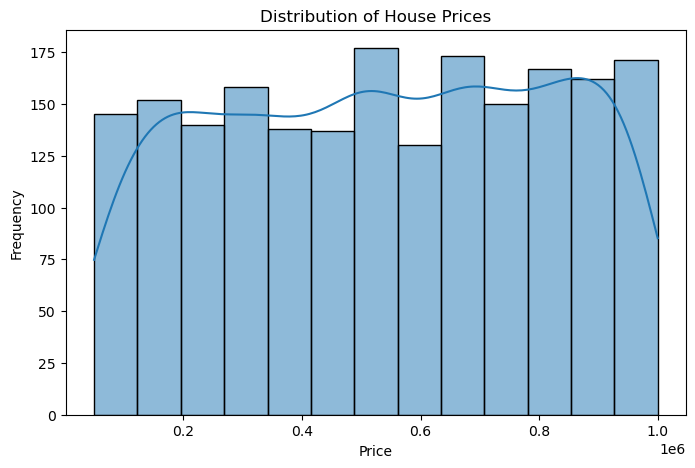

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price'], kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

## Feature analysis

In [18]:
numeric_features = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'Age',
    'Price'
]

df[numeric_features].describe()

,Area,Bedrooms,Bathrooms,Floors,Age,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,64.554000,537676.855000
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,501.000000,1.000000,1.00000,1.000000,3.000000,50005.000000
25%,1653.000000,2.000000,2.00000,1.000000,33.000000,300098.000000
50%,2833.000000,3.000000,3.00000,2.000000,65.000000,539254.000000
75%,3887.500000,4.000000,4.00000,3.000000,96.000000,780086.000000
max,4999.000000,5.000000,4.00000,3.000000,126.000000,999656.000000


## Analyze categorical features

In [19]:
print(df['Location'].value_counts())
print(df['Condition'].value_counts())
print(df['Garage'].value_counts())

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64
Garage
No     1038
Yes     962
Name: count, dtype: int64


## One-Hot Encoding

In [20]:
OneHotEncoder()

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


## Correlation heatmap

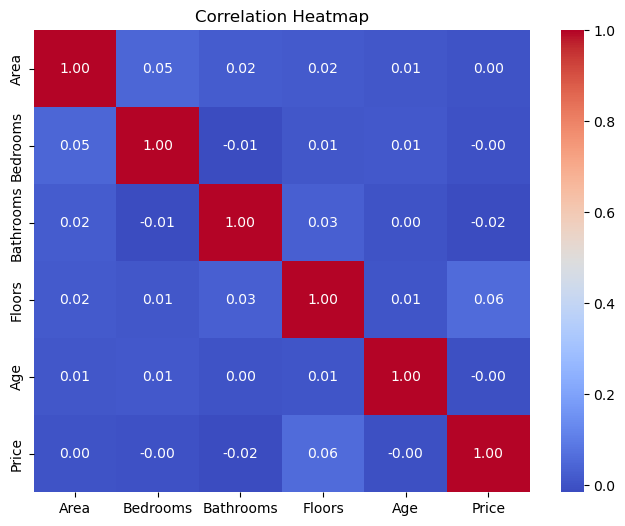

In [21]:
corr = df[
    ['Area', 'Bedrooms', 'Bathrooms',
     'Floors', 'Age', 'Price']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## Train/Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

* 80% ---> Training
* 20% --->Testing

## Separate numerical and categorical features

In [23]:
numeric_features = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'Age'
]

categorical_features = [
    'Location',
    'Condition',
    'Garage'
]

## Build preprocessing pipeline

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            SimpleImputer(strategy='median'),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

## Train Linear Regression

In [25]:
model=LinearRegression()

In [26]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [27]:
linear_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Make Predictions

In [28]:
y_pred = linear_model.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 78321466146.0328


In [30]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 279859.72583784326


In [31]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.006717808430749761


## Create Actual Vs Predicted plot

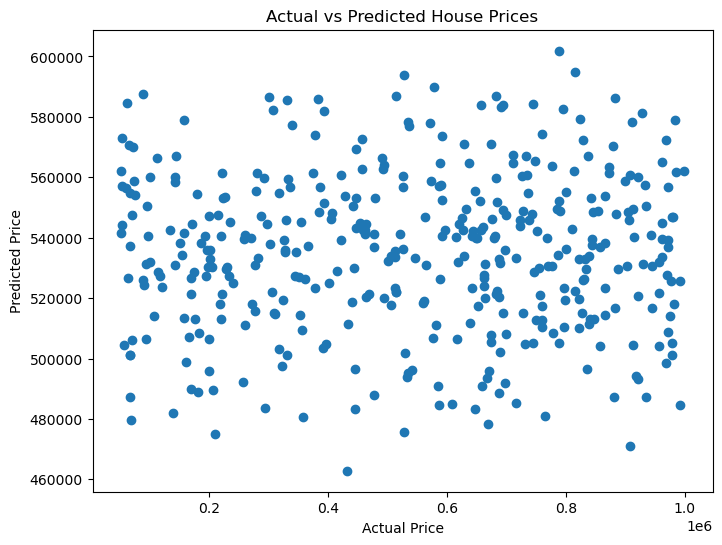

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted House Prices')

plt.show()

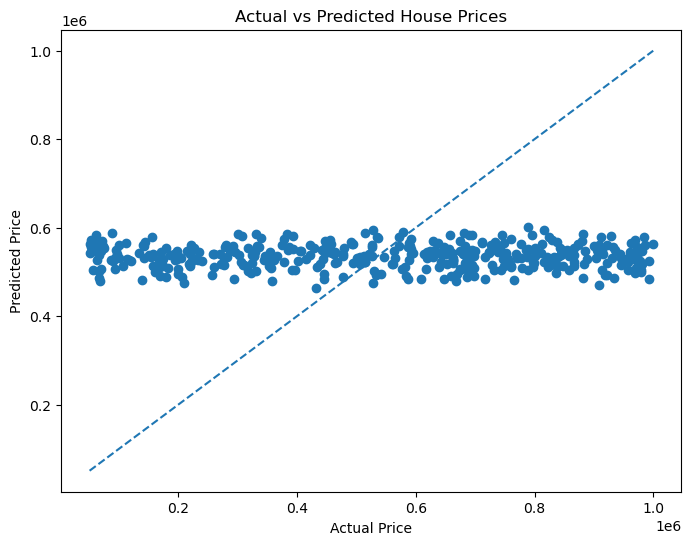

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted House Prices')

plt.show()

## Residual plot

In [34]:
residuals = y_test - y_pred

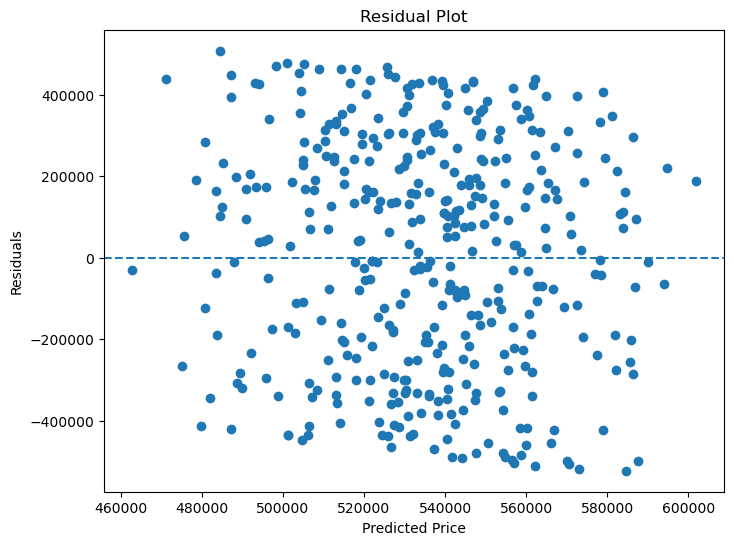

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')

plt.title('Residual Plot')

plt.show()

## Coefficient analysis

In [36]:
feature_names = (
    linear_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [37]:
coefficients = (
    linear_model
    .named_steps['model']
    .coef_
)

In [38]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

In [39]:
coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df

,Feature,Coefficient
8,cat__Condition_Fair,24083.307846
3,num__Floors,23727.983633
6,cat__Location_Suburban,11511.989815
10,cat__Condition_Poor,4073.268930
11,cat__Garage_Yes,2373.530579
5,cat__Location_Rural,1317.542020
1,num__Bedrooms,76.784827
0,num__Area,-0.575754
4,num__Age,-117.613885
2,num__Bathrooms,-9662.248234


## Ridge Regression comparison

In [40]:
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]
)

In [41]:
ridge_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
ridge_pred = ridge_model.predict(X_test)

In [43]:
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MSE: 78321268428.16655
Ridge RMSE: 279859.3725930339
Ridge R²: -0.0067152670317334184


## Compare linear Vs Ridge

In [44]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MSE': [mse, ridge_mse],
    'RMSE': [rmse, ridge_rmse],
    'R2': [r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R2
0,Linear Regression,7.832147e+10,279859.725838,-0.006718
1,Ridge Regression,7.832127e+10,279859.372593,-0.006715


## One concern with dataset
This is something I want you to understand because it is important for your project.
Your dataset looks structurally appropriate, but the relationships between the predictors and Price are extremely weak.

## Conclusion:-Final conclusion you can eventually write

Conclusion: A Linear Regression model was developed to predict house prices using area, number of bedrooms, bathrooms, floors, house age, location, condition, and garage availability. Categorical variables were converted using One-Hot Encoding and the dataset was divided into 80% training and 20% testing data. The model was evaluated using MSE, RMSE, and R². The Actual vs Predicted and residual plots were also analyzed. The results indicate that the available features have limited linear predictive power for house price in this dataset. Therefore, the Linear Regression model does not provide strong price predictions, suggesting that additional or more informative house-related features would be required for better predictive performance.